In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder



In [5]:
df = pd.read_csv(r"C:\Users\Rahul\Desktop\Codes\aiml\Machine Learning\LinearRegression\CarPricePrediction\Data\cardekho_dataset.csv")

In [7]:
df["age_mileage"] = df["vehicle_age"] * df["km_driven"]

In [8]:
df["log_selling_price"] = np.log1p(df["selling_price"])

In [9]:
X = df.drop(columns=["selling_price", "log_selling_price"])
y = df["log_selling_price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (15242, 12)
y shape: (15242,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (12193, 12)
Test set: (3049, 12)


In [11]:
categorical_features = [
    "brand",
    "model",
    "seller_type",
    "fuel_type",
    "transmission_type"
]

numerical_features = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats",
    "age_mileage"
]

In [12]:

encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(X_train[categorical_features])
X_test_cat = encoder.transform(X_test[categorical_features])

print("Encoded training shape:", X_train_cat.shape)
print("Encoded test shape:", X_test_cat.shape)

Encoded training shape: (12193, 154)
Encoded test shape: (3049, 154)


c:\Users\Rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [13]:
X_train_num = X_train[numerical_features].to_numpy()
X_test_num = X_test[numerical_features].to_numpy()

X_train_final = np.hstack([X_train_num, X_train_cat])
X_test_final = np.hstack([X_test_num, X_test_cat])

print("Final training shape:", X_train_final.shape)
print("Final test shape:", X_test_final.shape)

Final training shape: (12193, 161)
Final test shape: (3049, 161)


In [14]:
model = LinearRegression()

model.fit(X_train_final, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
y_pred_log = model.predict(X_test_final)

print(y_pred_log[:10])

y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

print("Predicted prices:", y_pred[:5])
print("Actual prices:", y_actual[:5])

[13.89560254 12.57832305 14.33659849 14.46857634 13.60774915 12.60373424
 13.20064293 13.5692876  13.33304979 14.62161883]
Predicted prices: [1083385.71110603  290198.25320199 1683857.57388791 1921421.47299229
  812399.8479394 ]
Actual prices: 10221     950000.0
12569     375000.0
11727    1690000.0
10166    1885000.0
14606     750000.0
Name: log_selling_price, dtype: float64


Model Evaluation

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print(f"MAE:  ₹{mae:,.2f}")
print(f"RMSE: ₹{rmse:,.2f}")
print(f"R²:   {r2:.4f}")

MAE:  ₹115,093.71
RMSE: ₹450,938.11
R²:   0.7494


In [18]:
n = X_test_final.shape[0]
p = X_test_final.shape[1]

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"Adjusted R²: {adjusted_r2:.4f}")

Adjusted R²: 0.7354


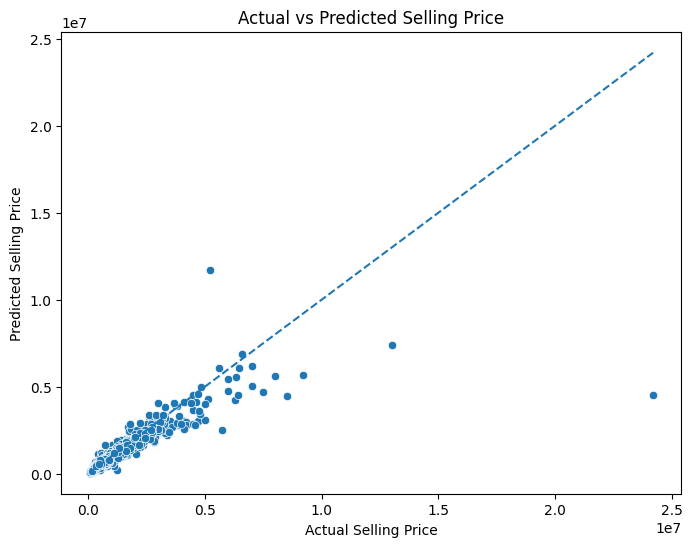

In [19]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_actual, y=y_pred)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

# Perfect prediction reference line
lims = [
    min(y_actual.min(), y_pred.min()),
    max(y_actual.max(), y_pred.max())
]

plt.plot(lims, lims, linestyle="--")

plt.show()

VIF / Multicollinearity

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[numerical_features].copy()

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

display(vif)

,Feature,VIF
6,age_mileage,10.854878
1,km_driven,6.863070
3,engine,6.286361
4,max_power,4.552602
0,vehicle_age,3.045139
5,seats,2.262611
2,mileage,1.950589


Regression Assumption Checks

In [22]:
residuals = y_test - y_pred_log

print("Mean residual:", residuals.mean())
print("Residual std:", residuals.std())

Mean residual: 0.004781500934323404
Residual std: 0.18299997017217026


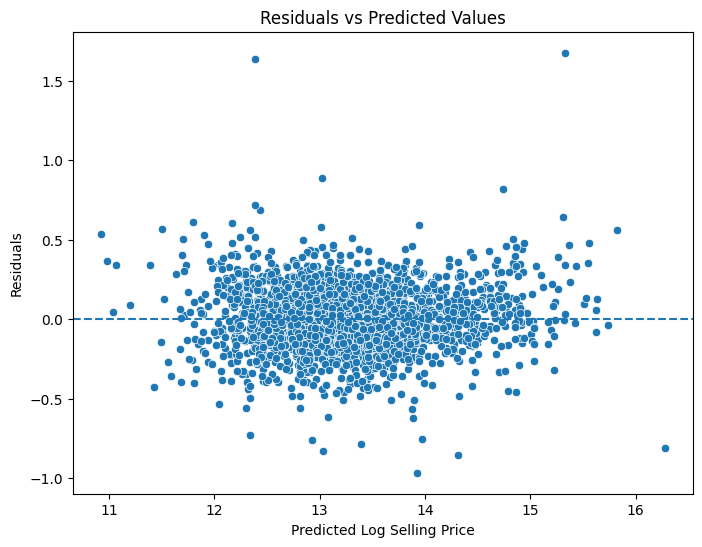

In [23]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_pred_log, y=residuals)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Log Selling Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.show()

<Figure size 800x600 with 0 Axes>

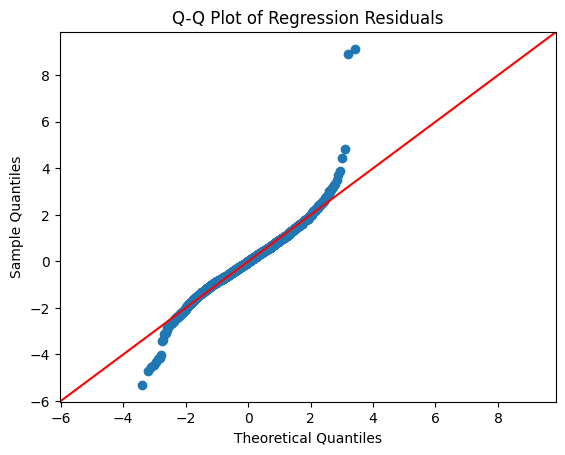

In [24]:
import statsmodels.api as sm

plt.figure(figsize=(8, 6))

sm.qqplot(residuals, line="45", fit=True)

plt.title("Q-Q Plot of Regression Residuals")
plt.show()

In [25]:
print("Residual skewness:", residuals.skew())
print("Residual mean:", residuals.mean())

Residual skewness: 0.3781938002501773
Residual mean: 0.004781500934323404


Model Refinement

In [27]:
numerical_features_v2 = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "max_power",
    "seats",
    "age_mileage"
]



X_train_num_v2 = X_train[numerical_features_v2].to_numpy()
X_test_num_v2 = X_test[numerical_features_v2].to_numpy()

X_train_v2 = np.hstack([X_train_num_v2, X_train_cat])
X_test_v2 = np.hstack([X_test_num_v2, X_test_cat])

print("Model B training shape:", X_train_v2.shape)

Model B training shape: (12193, 160)


In [28]:
X_train_num_v2 = X_train[numerical_features_v2].to_numpy()
X_test_num_v2 = X_test[numerical_features_v2].to_numpy()

X_train_v2 = np.hstack([X_train_num_v2, X_train_cat])
X_test_v2 = np.hstack([X_test_num_v2, X_test_cat])

print("Model B training shape:", X_train_v2.shape)

Model B training shape: (12193, 160)


In [29]:
model_v2 = LinearRegression()

model_v2.fit(X_train_v2, y_train)

y_pred_log_v2 = model_v2.predict(X_test_v2)

y_pred_v2 = np.expm1(y_pred_log_v2)

In [30]:
mae_v2 = mean_absolute_error(y_actual, y_pred_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_actual, y_pred_v2))
r2_v2 = r2_score(y_actual, y_pred_v2)

n = X_test_v2.shape[0]
p = X_test_v2.shape[1]

adjusted_r2_v2 = 1 - (1 - r2_v2) * (n - 1) / (n - p - 1)

print(f"Model B MAE:          ₹{mae_v2:,.2f}")
print(f"Model B RMSE:         ₹{rmse_v2:,.2f}")
print(f"Model B R²:           {r2_v2:.4f}")
print(f"Model B Adjusted R²:  {adjusted_r2_v2:.4f}")

Model B MAE:          ₹115,046.17
Model B RMSE:         ₹445,858.38
Model B R²:           0.7550
Model B Adjusted R²:  0.7414


Final VIF Check

In [31]:
X_vif_final = df[numerical_features_v2].copy()

vif_final = pd.DataFrame()
vif_final["Feature"] = X_vif_final.columns
vif_final["VIF"] = [
    variance_inflation_factor(X_vif_final.values, i)
    for i in range(X_vif_final.shape[1])
]

vif_final = vif_final.sort_values("VIF", ascending=False)

display(vif_final)

,Feature,VIF
5,age_mileage,10.815977
1,km_driven,6.862657
0,vehicle_age,3.044277
2,mileage,1.922069
3,max_power,1.459009
4,seats,1.328307


In [32]:
residuals_v2 = y_test - y_pred_log_v2

print("Residual mean:", residuals_v2.mean())
print("Residual skewness:", residuals_v2.skew())

Residual mean: 0.004788552952123615
Residual skewness: 0.35550651150212725


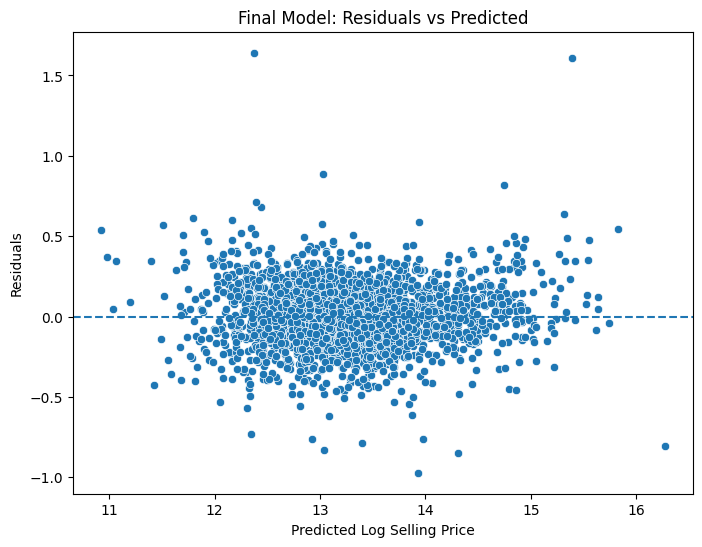

In [33]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_pred_log_v2, y=residuals_v2)

plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Log Selling Price")
plt.ylabel("Residuals")
plt.title("Final Model: Residuals vs Predicted")

plt.show()

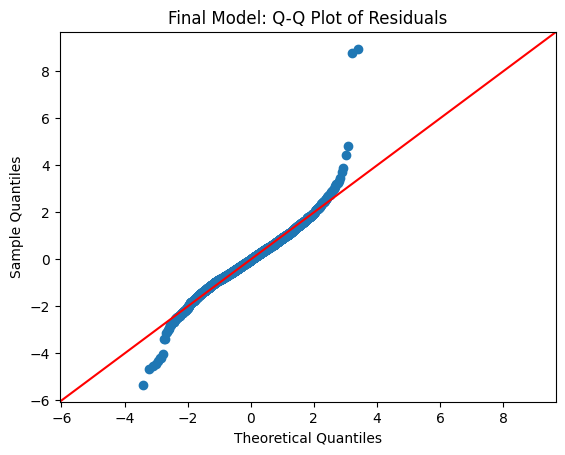

In [34]:
sm.qqplot(residuals_v2, line="45", fit=True)

plt.title("Final Model: Q-Q Plot of Residuals")
plt.show()

Prediction Pipeline

In [35]:
def predict_car_price(
    brand,
    model_name,
    vehicle_age,
    km_driven,
    seller_type,
    fuel_type,
    transmission_type,
    mileage,
    max_power,
    seats
):
    # Create input dataframe
    car = pd.DataFrame([{
        "brand": brand,
        "model": model_name,
        "vehicle_age": vehicle_age,
        "km_driven": km_driven,
        "seller_type": seller_type,
        "fuel_type": fuel_type,
        "transmission_type": transmission_type,
        "mileage": mileage,
        "max_power": max_power,
        "seats": seats
    }])

    # Required interaction
    car["age_mileage"] = car["vehicle_age"] * car["km_driven"]

    # Numerical features
    car_num = car[numerical_features_v2].to_numpy()

    # Categorical features
    car_cat = encoder.transform(car[categorical_features])

    # Combine features
    car_final = np.hstack([car_num, car_cat])

    # Predict log(price)
    predicted_log_price = model_v2.predict(car_final)[0]

    # Convert back to rupees
    predicted_price = np.expm1(predicted_log_price)

    return predicted_price

In [36]:
sample = df.iloc[0]

predicted_price = predict_car_price(
    brand=sample["brand"],
    model_name=sample["model"],
    vehicle_age=sample["vehicle_age"],
    km_driven=sample["km_driven"],
    seller_type=sample["seller_type"],
    fuel_type=sample["fuel_type"],
    transmission_type=sample["transmission_type"],
    mileage=sample["mileage"],
    max_power=sample["max_power"],
    seats=sample["seats"]
)

print("Actual price:    ₹{:,.0f}".format(sample["selling_price"]))
print("Predicted price: ₹{:,.0f}".format(predicted_price))

Actual price:    ₹120,000
Predicted price: ₹175,300


Final Model Evaluation & Documentation

In [37]:
results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²", "Adjusted R²"],
    "Value": [
        f"₹{mae_v2:,.2f}",
        f"₹{rmse_v2:,.2f}",
        f"{r2_v2:.4f}",
        f"{adjusted_r2_v2:.4f}"
    ]
})

display(results)

,Metric,Value
0,MAE,"₹115,046.17"
1,RMSE,"₹445,858.38"
2,R²,0.7550
3,Adjusted R²,0.7414


In [38]:
print("Final model: Multiple Linear Regression")
print("Target: log1p(selling_price)")
print("Training samples:", len(X_train))
print("Test samples:", len(X_test))
print("Encoded features:", X_train_v2.shape[1])

print("\nNumerical features:")
print(numerical_features_v2)

print("\nCategorical features:")
print(categorical_features)

Final model: Multiple Linear Regression
Target: log1p(selling_price)
Training samples: 12193
Test samples: 3049
Encoded features: 160

Numerical features:
['vehicle_age', 'km_driven', 'mileage', 'max_power', 'seats', 'age_mileage']

Categorical features:
['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']


In [39]:
import joblib

joblib.dump(model_v2, "linear_regression_model.pkl")
joblib.dump(encoder, "car_encoder.pkl")

print("Model and encoder saved successfully.")

Model and encoder saved successfully.


Performance by Price Segment

In [46]:
evaluation_df = pd.DataFrame({
    "actual_price": np.asarray(y_actual),
    "predicted_price": np.asarray(y_pred_v2)
})

evaluation_df["absolute_error"] = (
    evaluation_df["actual_price"] - evaluation_df["predicted_price"]
).abs()

evaluation_df["percentage_error"] = (
    evaluation_df["absolute_error"] /
    evaluation_df["actual_price"]
) * 100

In [47]:
def price_segment(price):
    if price < 300000:
        return "Budget (< ₹3L)"
    elif price < 800000:
        return "Mid-range (₹3L–₹8L)"
    elif price < 2000000:
        return "Premium (₹8L–₹20L)"
    else:
        return "Luxury (> ₹20L)"

evaluation_df["price_segment"] = (
    evaluation_df["actual_price"].apply(price_segment)
)

In [48]:
print(evaluation_df.columns.tolist())
display(evaluation_df.head())

['actual_price', 'predicted_price', 'absolute_error', 'percentage_error', 'price_segment']


,actual_price,predicted_price,absolute_error,percentage_error,price_segment
0,950000.0,1.081218e+06,131217.806802,13.812401,Premium (₹8L–₹20L)
1,375000.0,2.894795e+05,85520.454049,22.805454,Mid-range (₹3L–₹8L)
2,1690000.0,1.681292e+06,8707.548831,0.515240,Premium (₹8L–₹20L)
3,1885000.0,1.918721e+06,33720.508221,1.788886,Premium (₹8L–₹20L)
4,750000.0,8.104858e+05,60485.828255,8.064777,Mid-range (₹3L–₹8L)


In [49]:
segment_results = (
    evaluation_df
    .groupby("price_segment")
    .apply(
        lambda group: pd.Series({
            "Count": len(group),
            "MAE": mean_absolute_error(
                group["actual_price"],
                group["predicted_price"]
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    group["actual_price"],
                    group["predicted_price"]
                )
            ),
            "MAPE": group["percentage_error"].mean()
        }),
        include_groups=False
    )
)

display(segment_results)

,Count,MAE,RMSE,MAPE
price_segment,,,,
Budget (< ₹3L),430.0,43060.385641,5.743731e+04,19.716165
Luxury (> ₹20L),156.0,777768.794041,1.905222e+06,17.050596
Mid-range (₹3L–₹8L),1825.0,66930.272574,9.126869e+04,12.831328
Premium (₹8L–₹20L),638.0,139153.816163,1.908122e+05,11.931384


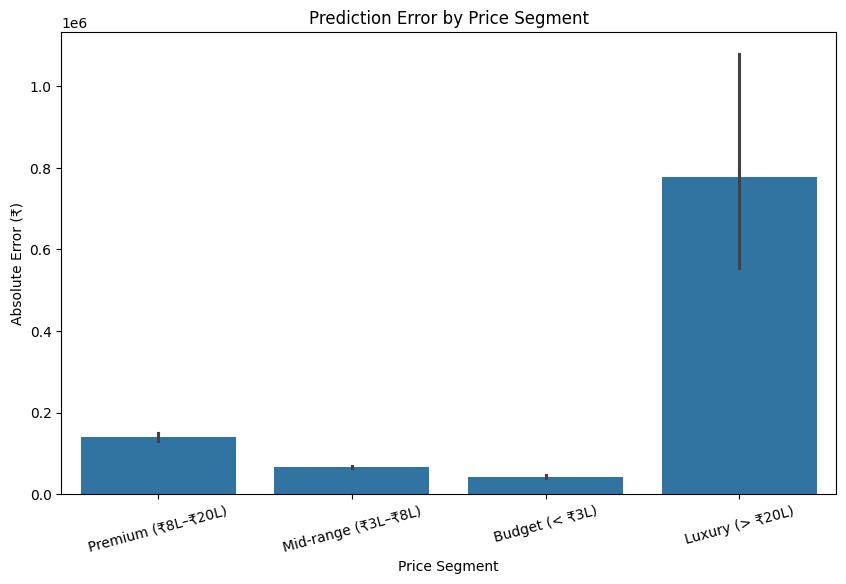

In [50]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=evaluation_df,
    x="price_segment",
    y="absolute_error"
)

plt.xlabel("Price Segment")
plt.ylabel("Absolute Error (₹)")
plt.title("Prediction Error by Price Segment")
plt.xticks(rotation=15)

plt.show()